# Sentiment Analysis with ANEW — *Spider-Man: Brand New Day*

| Etapa do enunciado | O que fizemos |
| --- | --- |
| Escolha de uma entidade | *Spider-Man: Brand New Day* (2026) — filme popular e nao controverso |
| Download de posts | 1000 reviews do IMDb, via `imdb_reviews_scraper.ipynb` |
| Sentimento medio via ANEW | media da valencia das palavras, com tratamento de negacao |
| Apresentacao | tres figuras, geradas na secao 9 |

**A pergunta.** O enunciado pede: *"find out if these posts are, on average,
good or bad"*. E uma pergunta **agregada**, e a resposta esta na secao 6.

**O diferencial deste analyzer.** Cada review do IMDb vem com a nota que o proprio
autor deu (1 a 10). Isso nos da um *ground truth* de graca: podemos medir se o ANEW
realmente acerta, em vez de so afirmar que funciona. Essa validacao esta na secao 7,
e ela mostra tanto o que o metodo consegue quanto o que ele nao consegue.

## 1. Setup e dados

In [1]:
import json
import os
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paleta: eixo azul-marinho + dourado da identidade visual, com o croma elevado ao
# minimo necessario para passar nos checks de acessibilidade (separacao CVD dE 25.8
# para protanopia, 29.7 para visao normal, contraste >= 3:1 contra o fundo).
AZUL, DOURADO = "#1F4E9C", "#A8762A"
TINTA, LINHA, FUNDO = "#0A1729", "#97A3B4", "#FCFCFB"

anew = pd.read_csv("anew.csv")
reviews = pd.read_csv("imdb_tt22084616_reviews.csv")
with open("imdb_tt22084616_reviews.json", encoding="utf-8") as fh:
    meta = json.load(fh)["meta"]

VALENCIA = dict(zip(anew["term"], anew["pleasure"]))
AROUSAL = dict(zip(anew["term"], anew["arousal"]))
DOMINANCE = dict(zip(anew["term"], anew["dominance"]))

print(f"entidade : {meta['title']} ({meta['year']}) — nota IMDb {meta['imdb_rating']}")
print(f"posts    : {len(reviews)} reviews (de {meta['reviews_available']} disponiveis)")
print(f"lexico   : ANEW com {len(anew)} termos")

entidade : Spider-Man: Brand New Day (2026) — nota IMDb 8.1
posts    : 1000 reviews (de 2509 disponiveis)
lexico   : ANEW com 1034 termos


## 2. Auditoria do lexico

O enunciado avisa: *"There might be inconsistencies in ANEW. You are expected to
figure out how to deal with them"*. Entao a primeira coisa e olhar o lexico, nao
sair usando.

O `anew.csv` que temos esta limpo — sem duplicatas, sem nulos, tudo minusculo.
Mas ha uma caracteristica que **muda o resultado inteiro** se ignorada.

In [2]:
print("=== integridade ===")
print(f"  termos                 : {len(anew)}")
print(f"  duplicados             : {anew['term'].duplicated().sum()}")
print(f"  com maiuscula          : {(anew['term'] != anew['term'].str.lower()).sum()}")
print(f"  nao alfabeticos        : {(~anew['term'].str.match(r'^[a-z]+$')).sum()}")
print(f"  valores nulos          : {anew.isna().sum().sum()}")

print("\n=== as tres dimensoes de Bradley & Lang (1999), escala 0-100 ===")
print("  pleasure  = valencia: quao agradavel e a palavra  <- e a dimensao de sentimento")
print("  arousal   = ativacao: quao excitante/calma        <- intensidade, nao valencia")
print("  dominance = controle: quao dominante/submisso")
for col in ["pleasure", "arousal", "dominance"]:
    print(f"    {col:<10} min={anew[col].min():5.2f}  max={anew[col].max():6.2f}  media={anew[col].mean():5.2f}")

MU = anew["pleasure"].mean()
print("\n=== a inconsistencia que importa: o ponto neutro NAO e 50 ===")
print(f"  media da valencia          : {MU:.2f}")
print(f"  mediana                    : {anew['pleasure'].median():.2f}")
print(f"  termos com pleasure > 50   : {(anew.pleasure > 50).sum()} ({100 * (anew.pleasure > 50).mean():.1f}%)")
print(f"  termos com pleasure < 50   : {(anew.pleasure < 50).sum()} ({100 * (anew.pleasure < 50).mean():.1f}%)")
print("\n  O ANEW foi montado com mais palavras agradaveis que desagradaveis.")
print("  Cortar em 50 chama 62% do lexico de 'positivo' antes de ver qualquer texto,")
print("  e por isso um classificador ingenuo com limiar 50 acha quase tudo positivo.")

=== integridade ===
  termos                 : 1034
  duplicados             : 0
  com maiuscula          : 0
  nao alfabeticos        : 0
  valores nulos          : 0

=== as tres dimensoes de Bradley & Lang (1999), escala 0-100 ===
  pleasure  = valencia: quao agradavel e a palavra  <- e a dimensao de sentimento
  arousal   = ativacao: quao excitante/calma        <- intensidade, nao valencia
  dominance = controle: quao dominante/submisso
    pleasure   min=14.17  max=100.00  media=58.38
    arousal    min=27.10  max= 92.63  media=58.03
    dominance  min=25.74  max= 89.34  media=56.75

=== a inconsistencia que importa: o ponto neutro NAO e 50 ===
  media da valencia          : 58.38
  mediana                    : 60.03
  termos com pleasure > 50   : 645 (62.4%)
  termos com pleasure < 50   : 389 (37.6%)

  O ANEW foi montado com mais palavras agradaveis que desagradaveis.
  Cortar em 50 chama 62% do lexico de 'positivo' antes de ver qualquer texto,
  e por isso um classificador inge

## 3. Pre-processamento e negacao

Duas decisoes aqui.

**Tokenizacao simples.** Remove pontuacao, minusculiza, separa por espaco. O ANEW so
tem palavras isoladas em forma base, entao nao ha ganho em stemming: `masterpieces`
nao esta no lexico de qualquer jeito, e forcar um stem criaria casamentos falsos.

**Negacao espelhada.** `"not good"` deveria contar como negativo, mas um contador
ingenuo le `good` e soma positivo. Quando a palavra anterior e um negador, espelhamos
a valencia em torno do neutro: `v -> 2 * MU - v`. Assim `good` (65) vira 51.7, do
outro lado do neutro.

> **Honestidade sobre o ganho.** Medimos, e a negacao praticamente nao move a
> correlacao com a nota do autor (secao 8). Ela altera o score de pouco mais de 100
> reviews, mas o efeito agregado e proximo de zero. Mantivemos porque e
> linguisticamente correta e barata — nao porque melhora o resultado. Negacao adjacente
> pega `"not good"`, e nao pega `"não é tão bom quanto parecia"`, que e a forma mais
> comum de negacao em texto real.

In [3]:
PONTUACAO = str.maketrans("", "", string.punctuation)

NEGADORES = {
    "not", "no", "never", "nothing", "none", "neither", "nor", "cannot", "cant",
    "dont", "doesnt", "didnt", "wasnt", "werent", "isnt", "arent", "wont",
    "wouldnt", "couldnt", "shouldnt", "without", "hardly", "barely", "rarely",
}


def tokenizar(texto):
    """Texto -> lista de palavras minusculas, sem pontuacao."""
    return texto.translate(PONTUACAO).lower().split()


def valencias(texto):
    """Valencia de cada palavra do texto presente no ANEW, com negacao espelhada."""
    palavras = tokenizar(texto)
    saida = []
    for i, palavra in enumerate(palavras):
        if palavra not in VALENCIA:
            continue
        v = VALENCIA[palavra]
        if i > 0 and palavras[i - 1] in NEGADORES:
            v = float(np.clip(2 * MU - v, 0, 100))
        saida.append(v)
    return saida


for frase in [
    "This movie is a masterpiece, pure joy and delight",
    "This movie is not good, a total failure",
    "The plot was fine, I guess",
]:
    vs = valencias(frase)
    medio = f"{np.mean(vs):.1f}" if vs else "-"
    print(f"  {frase}")
    print(f"    {len(vs)} palavras no ANEW, valencias {[round(v, 1) for v in vs]}, media {medio}\n")

  This movie is a masterpiece, pure joy and delight
    3 palavras no ANEW, valencias [77.8, 97.5, 93.7], media 89.6

  This movie is not good, a total failure
    3 palavras no ANEW, valencias [77.8, 32.1, 19.3], media 43.0

  The plot was fine, I guess
    0 palavras no ANEW, valencias [], media -



## 4. Do lexico para o post: como combinar

O enunciado coloca o problema central: *"although we have an affective rating for each
word, we do not have a rating for the whole post. You are expected to figure out a
possible way to combine this information"*.

Escolhemos a **media da valencia das palavras encontradas**, e nao a contagem de
palavras positivas versus negativas. O motivo e que a contagem joga fora a
intensidade: `masterpiece` (100) e `nice` (65) contam igual, embora nao digam a mesma
coisa. A secao 8 compara as duas medidas contra o ground truth — a media ganha.

**Abstencao por falta de evidencia.** Se o review tem menos de 3 palavras do ANEW, nao
pontuamos. Nao e um limiar ajustado para melhorar resultado: e admitir que a media de
uma ou duas palavras nao sustenta uma conclusao.

In [4]:
MIN_PALAVRAS = 3


def pontuar(texto):
    """Score do post = media da valencia das palavras ANEW encontradas (0-100).

    Devolve (score, quantas palavras casaram). Score NaN quando ha menos de
    MIN_PALAVRAS casamentos — sem evidencia suficiente para decidir.
    """
    vs = valencias(texto)
    if len(vs) < MIN_PALAVRAS:
        return np.nan, len(vs)
    return float(np.mean(vs)), len(vs)


print(f"  'a masterpiece of pure joy' -> {pontuar('a masterpiece of pure joy')}")
print(f"  'boring and awful garbage'  -> {pontuar('boring and awful garbage')}")
print(f"  'it was ok'                 -> {pontuar('it was ok')}  <- abstem, sem evidencia")

  'a masterpiece of pure joy' -> (nan, 1)
  'boring and awful garbage'  -> (nan, 1)
  'it was ok'                 -> (nan, 0)  <- abstem, sem evidencia


## 5. Aplicando aos 1000 reviews

In [5]:
resultado = reviews["review"].map(pontuar)
reviews["score"] = [r[0] for r in resultado]
reviews["n_anew"] = [r[1] for r in resultado]
reviews["n_palavras"] = reviews["review"].map(lambda t: len(tokenizar(t)))
reviews["cobertura"] = reviews["n_anew"] / reviews["n_palavras"]

print(f"  reviews pontuados          : {reviews['score'].notna().sum()} de {len(reviews)}")
print(f"  abstencoes (<{MIN_PALAVRAS} palavras ANEW): {reviews['score'].isna().sum()}")
print(f"  palavras ANEW por review   : mediana {reviews['n_anew'].median():.0f}, "
      f"min {reviews['n_anew'].min()}, max {reviews['n_anew'].max()}")
print(f"  cobertura do lexico        : {100 * reviews['cobertura'].mean():.1f}% das palavras")
print("\n  Cobertura baixa e esperada: o ANEW tem 1034 termos, entao a maior parte do")
print("  texto (artigos, nomes, verbos comuns) simplesmente nao tem valencia atribuida.")

  reviews pontuados          : 915 de 1000
  abstencoes (<3 palavras ANEW): 85
  palavras ANEW por review   : mediana 8, min 0, max 133
  cobertura do lexico        : 6.4% das palavras

  Cobertura baixa e esperada: o ANEW tem 1034 termos, entao a maior parte do
  texto (artigos, nomes, verbos comuns) simplesmente nao tem valencia atribuida.


## 6. A resposta agregada

Esta e a resposta que o enunciado pede. Comparamos o score medio do corpus com a media
do proprio lexico — ou seja, com a valencia da palavra tipica em ingles. O intervalo de
confianca vem de bootstrap, para nao apresentar uma media sem incerteza.

In [6]:
s = reviews["score"].dropna()
rng = np.random.default_rng(42)
amostras = np.array([rng.choice(s.values, len(s), replace=True).mean() for _ in range(2000)])
ic = np.percentile(amostras, [2.5, 97.5])

print("=== em media, os posts sao positivos ou negativos? ===")
print(f"  score medio do corpus      : {s.mean():.2f} / 100")
print(f"  IC 95% (bootstrap, n=2000) : [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"  neutro do lexico (media)   : {MU:.2f}")
print(f"  distancia do neutro        : {s.mean() - MU:+.2f} pontos")
print(f"  reviews acima do neutro    : {100 * (s > MU).mean():.1f}%")
print("\n  => O sentimento agregado em torno de Spider-Man: Brand New Day e POSITIVO.")
print("     O intervalo de confianca nao chega perto do neutro do lexico, entao a")
print("     conclusao nao depende de sorte na amostra.")

=== em media, os posts sao positivos ou negativos? ===
  score medio do corpus      : 72.06 / 100
  IC 95% (bootstrap, n=2000) : [71.56, 72.57]
  neutro do lexico (media)   : 58.38
  distancia do neutro        : +13.67 pontos
  reviews acima do neutro    : 95.1%

  => O sentimento agregado em torno de Spider-Man: Brand New Day e POSITIVO.
     O intervalo de confianca nao chega perto do neutro do lexico, entao a
     conclusao nao depende de sorte na amostra.


## 7. Validacao: o ANEW realmente acerta?

Aqui usamos a nota que cada autor deu ao proprio review. Nada disso entrou no calculo do
score — e um teste independente.

Tres medidas, em ordem de severidade: a correlacao (o score anda junto com a nota?), a
AUC (o score separa review bom de review ruim?), e a acuracia balanceada no melhor
limiar possivel (qual o teto do metodo?).

In [7]:
val = reviews.dropna(subset=["score", "rating"]).copy()
print(f"=== validacao contra a nota do autor (n={len(val)}) ===\n")

rho = val["score"].corr(val["rating"], method="spearman")
print(f"  Spearman score x nota : {rho:+.3f}   (positivo = anda na direcao certa)")

pos = val.loc[val["rating"] >= 7, "score"].values
neg = val.loc[val["rating"] <= 4, "score"].values
auc = np.mean([[(p > n) + 0.5 * (p == n) for n in neg] for p in pos])
print(f"  AUC (nota>=7 vs nota<=4): {auc:.3f}   (0.50 = moeda, 1.00 = perfeito)")
print(f"     n positivos={len(pos)}, n negativos={len(neg)}")

grade = np.arange(55, 90, 0.25)
balanceada = [0.5 * ((pos > t).mean() + (neg <= t).mean()) for t in grade]
LIMIAR = float(grade[int(np.argmax(balanceada))])
print(f"\n  melhor limiar unico   : {LIMIAR:.2f}")
print(f"  acuracia balanceada   : {100 * max(balanceada):.1f}%")
print(f"  (chutar sempre 'positivo' acerta {100 * len(pos) / (len(pos) + len(neg)):.1f}% —")
print("   por isso acuracia crua engana aqui, e usamos a balanceada)")

print("\n=== score medio por nota do autor ===")
for nota in range(1, 11):
    m = val[val["rating"] == nota]
    if len(m):
        barra = "#" * int(round((m["score"].mean() - 60) * 2))
        print(f"  nota {nota:>2}  n={len(m):>3}  score={m['score'].mean():.2f}  {barra}")

print("\n=== leitura honesta ===")
print(f"  O sinal existe e e monotonico, mas e fraco: AUC {auc:.2f} significa que, sorteando")
print("  um review bem avaliado e um mal avaliado, o score acerta qual e qual em cerca de")
print(f"  {100 * auc:.0f}% dos pares. Melhor que moeda, longe de confiavel por review individual.")
print("  A conclusao agregada da secao 6 e solida; a classificacao review a review, nao.")

=== validacao contra a nota do autor (n=899) ===

  Spearman score x nota : +0.210   (positivo = anda na direcao certa)
  AUC (nota>=7 vs nota<=4): 0.699   (0.50 = moeda, 1.00 = perfeito)
     n positivos=702, n negativos=60

  melhor limiar unico   : 72.25
  acuracia balanceada   : 67.7%
  (chutar sempre 'positivo' acerta 92.1% —
   por isso acuracia crua engana aqui, e usamos a balanceada)

=== score medio por nota do autor ===
  nota  1  n= 34  score=67.57  ###############
  nota  2  n=  5  score=65.52  ###########
  nota  3  n= 11  score=67.00  ##############
  nota  4  n= 10  score=70.02  ####################
  nota  5  n= 27  score=69.42  ###################
  nota  6  n=110  score=70.52  #####################
  nota  7  n=160  score=71.29  #######################
  nota  8  n=124  score=72.48  #########################
  nota  9  n=152  score=73.44  ###########################
  nota 10  n=266  score=73.64  ###########################

=== leitura honesta ===
  O sinal existe e 

## 8. Por que media e nao contagem

Toda decisao de projeto aqui foi medida, nao escolhida por gosto. A metrica de comparacao
e a correlacao de Spearman com a nota do autor: quanto maior, melhor o score captura o
que o leitor de fato sentiu.

In [8]:
def spearman_de(fn):
    """Correlacao de Spearman entre um score qualquer e a nota do autor."""
    sc = reviews["review"].map(fn)
    ok = sc.notna() & reviews["rating"].notna()
    return sc[ok].corr(reviews["rating"][ok], method="spearman"), ok.sum()


def media_simples(texto):
    vs = [VALENCIA[w] for w in tokenizar(texto) if w in VALENCIA]
    return np.mean(vs) if len(vs) >= MIN_PALAVRAS else np.nan


def contagem(texto, limiar):
    vs = [VALENCIA[w] for w in tokenizar(texto) if w in VALENCIA]
    if len(vs) < MIN_PALAVRAS:
        return np.nan
    return (sum(v > limiar for v in vs) - sum(v < limiar for v in vs)) / len(vs)


def media_de(tabela):
    def fn(texto):
        vs = [tabela[w] for w in tokenizar(texto) if w in tabela]
        return np.mean(vs) if len(vs) >= MIN_PALAVRAS else np.nan
    return fn


variantes = {
    "contagem pos/neg, limiar 50": lambda t: contagem(t, 50),
    "contagem pos/neg, limiar 58.4 (media)": lambda t: contagem(t, MU),
    "media da valencia": media_simples,
    "media da valencia + negacao  <- escolhido": lambda t: pontuar(t)[0],
    "media do arousal (controle)": media_de(AROUSAL),
    "media do dominance (controle)": media_de(DOMINANCE),
}

print(f"{'variante':<44} {'Spearman':>9}  {'n':>5}")
print("-" * 62)
medidas = {}
for nome, fn in variantes.items():
    r, n = spearman_de(fn)
    medidas[nome] = r
    print(f"{nome:<44} {r:>+9.3f}  {n:>5}")

r_cont50 = medidas["contagem pos/neg, limiar 50"]
r_contmu = medidas["contagem pos/neg, limiar 58.4 (media)"]
r_media = medidas["media da valencia"]
r_neg = medidas["media da valencia + negacao  <- escolhido"]
r_arou = medidas["media do arousal (controle)"]
r_domi = medidas["media do dominance (controle)"]

sem_neg = reviews["review"].map(media_simples)
mudou = int(((sem_neg != reviews["score"]) & sem_neg.notna() & reviews["score"].notna()).sum())

print("\n  Leitura das medidas:")
print(f"  1. A media ({r_media:+.3f}) bate a contagem ({r_cont50:+.3f}): a intensidade da")
print("     palavra informa, e contar joga essa informacao fora.")
print(f"  2. Corrigir o limiar da contagem de 50 para 58.4 leva de {r_cont50:+.3f} a "
      f"{r_contmu:+.3f} —")
print("     ajuda, mas menos que trocar contagem por media. O corte errado era parte do")
print("     problema; a outra parte era descartar a magnitude.")
print(f"  3. A negacao move de {r_media:+.4f} para {r_neg:+.4f}, alterando o score de "
      f"{mudou} reviews.")
print("     Ou seja: praticamente nada. Mantida por correcao linguistica, nao por ganho.")
print(f"  4. Arousal ({r_arou:+.3f}) e dominance ({r_domi:+.3f}) carregam sinal menor que a")
print("     valencia, como Bradley & Lang preveem: valencia e a dimensao agradavel/")
print("     desagradavel, enquanto arousal e intensidade — e um review pode ser")
print("     intensamente negativo.")

variante                                      Spearman      n
--------------------------------------------------------------
contagem pos/neg, limiar 50                     +0.161    899
contagem pos/neg, limiar 58.4 (media)           +0.174    899
media da valencia                               +0.210    899
media da valencia + negacao  <- escolhido       +0.210    899
media do arousal (controle)                     +0.123    899
media do dominance (controle)                   +0.130    899

  Leitura das medidas:
  1. A media (+0.210) bate a contagem (+0.161): a intensidade da
     palavra informa, e contar joga essa informacao fora.
  2. Corrigir o limiar da contagem de 50 para 58.4 leva de +0.161 a +0.174 —
     ajuda, mas menos que trocar contagem por media. O corte errado era parte do
     problema; a outra parte era descartar a magnitude.
  3. A negacao move de +0.2095 para +0.2105, alterando o score de 130 reviews.
     Ou seja: praticamente nada. Mantida por correcao linguisti

## 9. Figuras

Tres figuras, salvas em `figuras/`. Nenhuma e grafico de pizza, conforme o enunciado.

A **figura 1** e a candidata ao slide de resultados: responde a pergunta agregada numa
imagem. As figuras 2 e 3 sustentam a validacao.

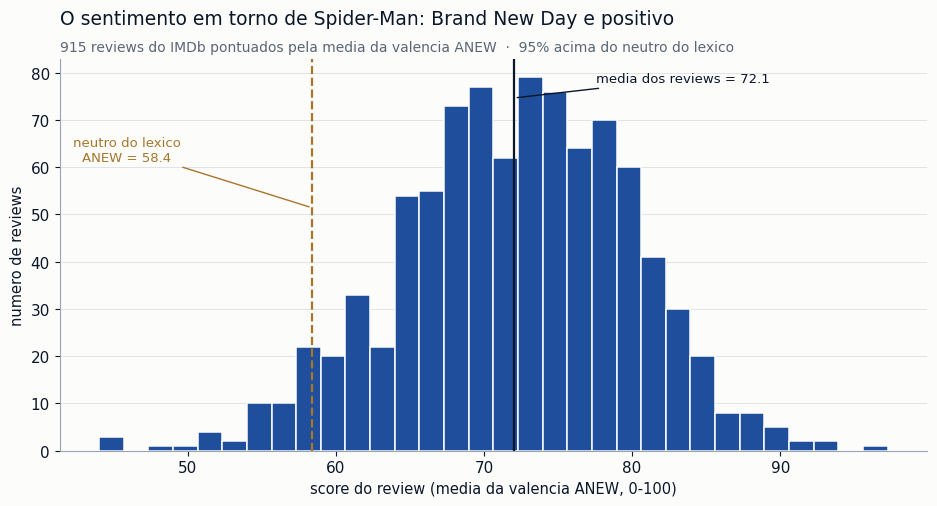

In [9]:
os.makedirs("figuras", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO,
    "text.color": TINTA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.edgecolor": LINHA, "font.size": 11,
})


def limpar(ax, titulo, sub=None, xlabel=None, ylabel=None):
    """Grid recessivo, sem moldura, titulo alinhado a esquerda.

    O pad do titulo cresce com o numero de linhas do subtitulo: o subtitulo e
    ancorado por baixo (va='bottom') e cresce para cima, entao o titulo precisa
    ser empurrado o suficiente para nao colidir com ele.
    """
    linhas = sub.count("\n") + 1 if sub else 0
    ax.set_title(titulo, fontsize=13.5, loc="left", pad=10 + 15 * linhas)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=10, color="#5A6675",
                va="bottom", linespacing=1.45)
    ax.set_xlabel(xlabel or "", fontsize=10.5)
    ax.set_ylabel(ylabel or "", fontsize=10.5)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.grid(axis="y", color=LINHA, alpha=0.28, lw=0.7)
    ax.set_axisbelow(True)


# ---------- Figura 1: distribuicao dos scores ----------
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(s, bins=32, color=AZUL, edgecolor=FUNDO, linewidth=1.1)
ax.axvline(MU, color=DOURADO, lw=1.6, ls="--")
ax.axvline(s.mean(), color=TINTA, lw=1.6)

topo = ax.get_ylim()[1]
ax.annotate(f"neutro do lexico\nANEW = {MU:.1f}", xy=(MU, topo * 0.62),
            xytext=(MU - 12.5, topo * 0.74), fontsize=9.5, color=DOURADO,
            ha="center", arrowprops=dict(arrowstyle="-", color=DOURADO, lw=1))
ax.annotate(f"media dos reviews = {s.mean():.1f}", xy=(s.mean(), topo * 0.9),
            xytext=(s.mean() + 5.5, topo * 0.94), fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle="-", color=TINTA, lw=1))

limpar(ax, "O sentimento em torno de Spider-Man: Brand New Day e positivo",
       sub=f"{len(s)} reviews do IMDb pontuados pela media da valencia ANEW  ·  "
           f"{100 * (s > MU).mean():.0f}% acima do neutro do lexico",
       xlabel="score do review (media da valencia ANEW, 0-100)", ylabel="numero de reviews")
fig.tight_layout()
fig.savefig("figuras/fig1_distribuicao.png", dpi=200)
plt.show()

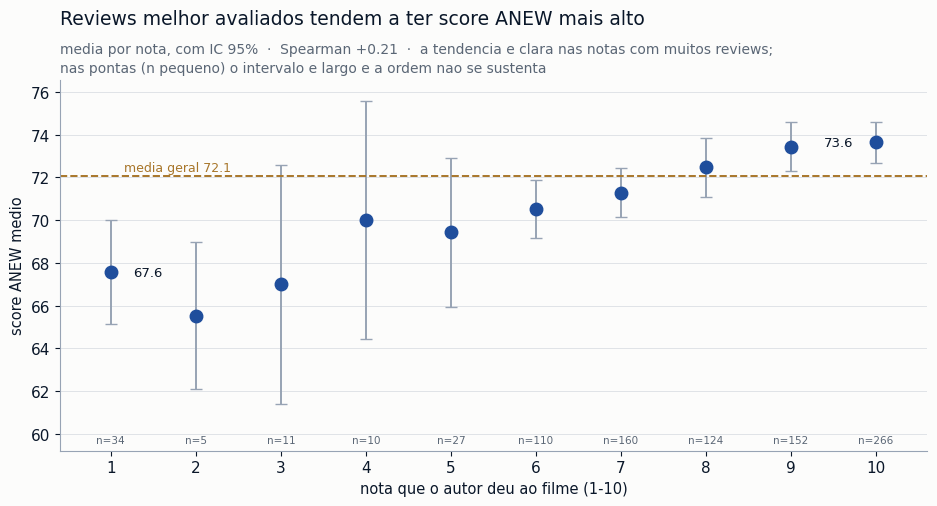

In [10]:
# ---------- Figura 2: score medio por nota do autor ----------
g = val.groupby("rating")["score"]
medias, tamanhos, erros = g.mean(), g.size(), g.std() / np.sqrt(g.size())

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.errorbar(medias.index, medias.values, yerr=1.96 * erros.values, fmt="o",
            color=AZUL, markersize=9, lw=0, elinewidth=1.4, ecolor=LINHA, capsize=4)
ax.axhline(s.mean(), color=DOURADO, lw=1.4, ls="--")

# folga vertical calculada a partir das barras, para os rotulos n= nao colidirem
baixo = (medias - 1.96 * erros).min()
alto = (medias + 1.96 * erros).max()
ax.set_ylim(baixo - 2.2, alto + 1.0)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.4, 10.6)

ax.text(1.15, s.mean() + 0.25, f"media geral {s.mean():.1f}", fontsize=9, color=DOURADO)

# rotulo direto apenas nos extremos, deslocado na horizontal para nao cruzar a barra
for nota, lado in [(medias.index.min(), 1), (medias.index.max(), -1)]:
    ax.annotate(f"{medias[nota]:.1f}", (nota, medias[nota]), textcoords="offset points",
                xytext=(16 * lado, -3), ha="left" if lado > 0 else "right",
                fontsize=9.5, color=TINTA)

for nota, n in tamanhos.items():
    ax.annotate(f"n={n}", (nota, ax.get_ylim()[0] + 0.35), ha="center",
                fontsize=7.5, color="#5A6675")

limpar(ax, "Reviews melhor avaliados tendem a ter score ANEW mais alto",
       sub=f"media por nota, com IC 95%  ·  Spearman {rho:+.2f}  ·  a tendencia e clara nas "
           "notas com muitos reviews;\nnas pontas (n pequeno) o intervalo e largo e a ordem "
           "nao se sustenta",
       xlabel="nota que o autor deu ao filme (1-10)", ylabel="score ANEW medio")
fig.tight_layout()
fig.savefig("figuras/fig2_score_por_nota.png", dpi=200)
plt.show()

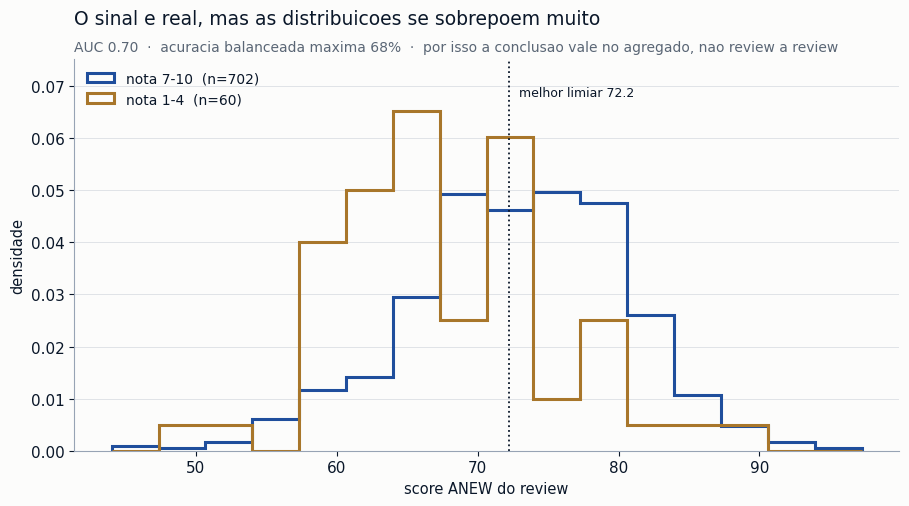

figuras salvas: fig1_distribuicao.png, fig2_score_por_nota.png, fig3_sobreposicao.png


In [11]:
# ---------- Figura 3: sobreposicao entre bem e mal avaliados ----------
fig, ax = plt.subplots(figsize=(9.5, 5.2))
# menos faixas: com n=60 no grupo negativo, 25 bins viram serrilhado sem informacao
faixas = np.linspace(min(pos.min(), neg.min()), max(pos.max(), neg.max()), 17)
ax.hist(pos, bins=faixas, density=True, histtype="step", lw=2.2, color=AZUL,
        label=f"nota 7-10  (n={len(pos)})")
ax.hist(neg, bins=faixas, density=True, histtype="step", lw=2.2, color=DOURADO,
        label=f"nota 1-4  (n={len(neg)})")
ax.set_ylim(top=ax.get_ylim()[1] * 1.10)  # respiro: o pico encostava na borda
ax.axvline(LIMIAR, color=TINTA, lw=1.3, ls=":")
ax.text(LIMIAR + 0.7, ax.get_ylim()[1] * 0.93, f"melhor limiar {LIMIAR:.1f}",
        fontsize=9, color=TINTA, va="top")

limpar(ax, "O sinal e real, mas as distribuicoes se sobrepoem muito",
       sub=f"AUC {auc:.2f}  ·  acuracia balanceada maxima {100 * max(balanceada):.0f}%  ·  "
           "por isso a conclusao vale no agregado, nao review a review",
       xlabel="score ANEW do review", ylabel="densidade")
ax.legend(frameon=False, loc="upper left", fontsize=10)
fig.tight_layout()
fig.savefig("figuras/fig3_sobreposicao.png", dpi=200)
plt.show()

print("figuras salvas:", ", ".join(sorted(os.listdir("figuras"))))

## 10. Resumo numerico

Os numeros abaixo sao calculados, nao transcritos — se voce recoletar os reviews, eles se
atualizam sozinhos. Use esta saida para preencher os slides.

In [12]:
print("=" * 66)
print(f"ENTIDADE   {meta['title']} ({meta['year']})")
print(f"FONTE      IMDb — {len(reviews)} reviews de {meta['reviews_available']} disponiveis")
print(f"METODO     media da valencia ANEW, negacao adjacente, abstencao < {MIN_PALAVRAS} palavras")
print("=" * 66)
print(f"\nRESPOSTA AGREGADA")
print(f"  score medio do corpus    {s.mean():.2f} / 100")
print(f"  IC 95% (bootstrap)       [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"  neutro do lexico ANEW    {MU:.2f}")
print(f"  reviews acima do neutro  {100 * (s > MU).mean():.1f}%")
print(f"  veredito                 POSITIVO")
print(f"\nCONFIABILIDADE (contra a nota do autor, n={len(val)})")
print(f"  Spearman                 {rho:+.3f}")
print(f"  AUC (>=7 vs <=4)         {auc:.3f}")
print(f"  acuracia balanceada      {100 * max(balanceada):.1f}% no melhor limiar ({LIMIAR:.1f})")
print(f"\nCOBERTURA")
print(f"  palavras casadas no ANEW {100 * reviews['cobertura'].mean():.1f}%")
print(f"  reviews pontuados        {reviews['score'].notna().sum()} de {len(reviews)}")
print(f"  abstencoes               {reviews['score'].isna().sum()}")
print("=" * 66)

ENTIDADE   Spider-Man: Brand New Day (2026)
FONTE      IMDb — 1000 reviews de 2509 disponiveis
METODO     media da valencia ANEW, negacao adjacente, abstencao < 3 palavras

RESPOSTA AGREGADA
  score medio do corpus    72.06 / 100
  IC 95% (bootstrap)       [71.56, 72.57]
  neutro do lexico ANEW    58.38
  reviews acima do neutro  95.1%
  veredito                 POSITIVO

CONFIABILIDADE (contra a nota do autor, n=899)
  Spearman                 +0.210
  AUC (>=7 vs <=4)         0.699
  acuracia balanceada      67.7% no melhor limiar (72.2)

COBERTURA
  palavras casadas no ANEW 6.4%
  reviews pontuados        915 de 1000
  abstencoes               85


## 11. O que vai nos slides

### Slide 1 — como o algoritmo funciona

Sem codigo, conforme o enunciado. O essencial:

1. Tokenizar o review e casar cada palavra com o ANEW (1034 termos, escala 0-100).
2. Se a palavra anterior nega, espelhar a valencia em torno do neutro: `v -> 2μ - v`.
3. Score do review = **media** das valencias casadas (media, nao contagem: preserva
   intensidade).
4. Abster quando ha menos de 3 palavras do ANEW.
5. Comparar o score medio do corpus com μ = 58,4, a valencia da palavra tipica.

Vale destacar no slide a decisao que os colegas provavelmente nao tomaram: **o neutro do
ANEW e 58,4, nao 50**. O lexico tem 62% de termos acima de 50, e cortar em 50 faz
qualquer texto parecer positivo.

### Slide 2 — resultados

Use `figuras/fig1_distribuicao.png`: a distribuicao dos 1000 scores com o neutro do
lexico e a media do corpus marcados. Responde a pergunta numa imagem, sem pizza.

Se couber uma segunda figura, `fig3_sobreposicao.png` mostra o limite do metodo — e
admitir limitacao com numero e mais forte que omitir.

### Limitacoes

Todas verificadas nas secoes acima, com numero na celula 10:

- **Cobertura baixa.** Cerca de 1 palavra em 16 esta no ANEW; o resto do texto nao vota.
  O lexico tem 1034 termos, e reviews de cinema usam vocabulario que ele nao cobre.
- **Separacao modesta.** A AUC fica perto de 0,70: sorteando um review bem avaliado e um
  mal avaliado, o score acerta qual e qual em ~70% dos pares. Serve para o agregado, nao
  para decidir um review isolado.
- **Vocabulario de dominio distorce.** Num filme de super-heroi, `villain`, `fight`,
  `death` e `war` aparecem como descricao de trama, mas o ANEW lhes da valencia baixa.
  O metodo le trama como sentimento.
- **Negacao apenas adjacente.** Pega `"not good"`; nao pega `"nao tao bom quanto o
  anterior"`, nem ironia, nem comparacao.
- **Amostra enviesada.** Os reviews foram coletados por `HELPFULNESS_SCORE`, ou seja os
  mais votados como uteis — nao uma amostra aleatoria. Isso favorece textos longos e
  elaborados, e provavelmente inflaciona a proporcao de reviews positivos.